<a href="https://colab.research.google.com/github/seobojung/ABCD-A/blob/20250529/yolov8_retry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# YOLOv8 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [2]:
# 필요한 라이브러리 임포트
import os
from ultralytics import YOLO
import shutil
from google.colab import drive
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# 파일 선택기를 통한 업로드
uploaded = files.upload()

Saving Test.v1i.yolov8.zip.zip to Test.v1i.yolov8.zip.zip


In [4]:
# 코랩 셀에서 ! 를 앞에 붙여서 실행
!mkdir -p /content/dataset
!unzip /content/Test.v1i.yolov8.zip -d /content/dataset

Archive:  /content/Test.v1i.yolov8.zip.zip
  inflating: /content/dataset/README.dataset.txt  
  inflating: /content/dataset/README.roboflow.txt  
  inflating: /content/dataset/data.yaml  
   creating: /content/dataset/train/
   creating: /content/dataset/train/images/
 extracting: /content/dataset/train/images/1-_jpg.rf.92e5e7c348cbd67ffb055fb1193d262c.jpg  
 extracting: /content/dataset/train/images/10-_jpg.rf.f0d7fe7ce9f97945e347607298484513.jpg  
 extracting: /content/dataset/train/images/11-_jpg.rf.a1185d8205863bf18827b6be290bdd8c.jpg  
 extracting: /content/dataset/train/images/12-_jpg.rf.176e6aae1199ceb09288c5285f592366.jpg  
 extracting: /content/dataset/train/images/13-_jpg.rf.ffb5f43a8dda72af2aeff89e6a5ff444.jpg  
 extracting: /content/dataset/train/images/14-_jpg.rf.dff7bd7961498781614b4a10ac9d89a1.jpg  
 extracting: /content/dataset/train/images/15-_jpg.rf.170b2025d093abbf922b1b3eaa0addf3.jpg  
 extracting: /content/dataset/train/images/2-_jpg.rf.a675c6d9417aa54be34457d51a1e

In [5]:
#test/images 폴더 생성
!mkdir -p /content/dataset/test/images
!cp /content/dataset/train/images/* /content/dataset/test/images/

In [6]:
#valid/images 폴더 생성
!mkdir -p /content/dataset/valid/images
!cp /content/dataset/train/images/* /content/dataset/valid/images/

In [7]:
#valid/labels 폴더 생성
!mkdir -p /content/dataset/valid/labels
!cp /content/dataset/train/labels/* /content/dataset/valid/labels/

In [8]:
# 학습 시작
from ultralytics import YOLO

# Label 모델로 학습
model = YOLO("yolov8l.pt")  # 크기에 따라서 x,s,m,l 등 모델 사용  yolov8s.pt, yolov8m.pt 등

results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolov8_label_custom',
    project='/content/runs/train',
    patience=10,
    save=True,
    device=0
)

100%|██████████| 83.7M/83.7M [00:00<00:00, 266MB/s]


Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_label_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0, pr

100%|██████████| 755k/755k [00:00<00:00, 19.9MB/s]

Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              


  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  3   4461568  ultralytics.nn.modules.block.C2f             [512, 512, 3, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  3   4723712  ultralytics.nn.modules.block.C2f             [1024, 512, 3]                
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]  

...

      50/50      9.06G     0.5443     0.6113     0.9554        127        640: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.95it/s]

                   all         15        129      0.843      0.744      0.823      0.673



50 epochs completed in 0.108 hours.
Optimizer stripped from /content/runs/train/yolov8_label_custom/weights/last.pt, 87.7MB
Optimizer stripped from /content/runs/train/yolov8_label_custom/weights/best.pt, 87.7MB

Validating /content/runs/train/yolov8_label_custom/weights/best.pt...
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 112 layers, 43,610,463 parameters, 0 gradients, 164.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.91it/s]


                   all         15        129      0.716      0.773      0.821      0.705
           dotted-line         15         60          1      0.798      0.989      0.791
             left-lane         15         15      0.811      0.933      0.948      0.825
             left_line         15         20      0.183       0.45      0.399      0.352
            right-lane         15         15      0.659          1      0.961      0.816
            right_line         15         19      0.927      0.684       0.81      0.742
Speed: 0.2ms preprocess, 16.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/train/yolov8_label_custom


In [16]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

/content/yolo11n.pt
/content/yolov8l.pt
/content/runs/train/yolov8_label_custom/weights/last.pt
/content/runs/train/yolov8_label_custom/weights/best.pt


In [17]:
# 학습된 모델 로드(폴더에 맞도록)
model = YOLO('/content/runs/train/yolov8_label_custom/weights/best.pt')

# 테스트 실행
results = model.predict(
    source='/content/dataset/test/images',  # 테스트 이미지 경로
    save=True,                              # 결과 저장
    save_txt=True,                          # 텍스트 결과도 저장
    conf=0.5,                               # 신뢰도 임계값
    project='/content',         # 저장 프로젝트 경로
    name='Test.v1i.yolov8.zip.zip'                     # 폴더 이름 지정
)


image 1/15 /content/dataset/test/images/1-_jpg.rf.92e5e7c348cbd67ffb055fb1193d262c.jpg: 640x640 3 dotted-lines, 2 left-lanes, 8 left_lines, 2 right-lanes, 1 right_line, 62.6ms
image 2/15 /content/dataset/test/images/10-_jpg.rf.f0d7fe7ce9f97945e347607298484513.jpg: 640x640 3 dotted-lines, 3 left-lanes, 6 left_lines, 3 right-lanes, 1 right_line, 43.4ms
image 3/15 /content/dataset/test/images/11-_jpg.rf.a1185d8205863bf18827b6be290bdd8c.jpg: 640x640 4 dotted-lines, 2 left-lanes, 6 left_lines, 2 right-lanes, 1 right_line, 43.3ms
image 4/15 /content/dataset/test/images/12-_jpg.rf.176e6aae1199ceb09288c5285f592366.jpg: 640x640 4 dotted-lines, 2 left-lanes, 5 left_lines, 2 right-lanes, 1 right_line, 40.1ms
image 5/15 /content/dataset/test/images/13-_jpg.rf.ffb5f43a8dda72af2aeff89e6a5ff444.jpg: 640x640 4 dotted-lines, 3 left-lanes, 5 left_lines, 2 right-lanes, 1 right_line, 39.6ms
image 6/15 /content/dataset/test/images/14-_jpg.rf.dff7bd7961498781614b4a10ac9d89a1.jpg: 640x640 4 dotted-lines, 2 

In [18]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def draw_bbox_results(image_path, results):
    """바운딩 박스를 이미지 위에 시각화"""
    # 이미지 로드
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 클래스 이름 및 색상
    class_names = ['dotted-line', 'left_lane', 'left_line', 'right_lane', 'right_line']
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

    for result in results:
        boxes = result.boxes  # 바운딩 박스 객체

        if boxes is not None:
            xyxy = boxes.xyxy.cpu().numpy()  # (N, 4)
            cls_list = boxes.cls.cpu().numpy().astype(int)
            conf_list = boxes.conf.cpu().numpy()

            for i in range(len(xyxy)):
                x1, y1, x2, y2 = xyxy[i].astype(int)
                cls_id = cls_list[i]
                conf = conf_list[i]

                color = colors[cls_id % len(colors)]
                class_name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
                label = f'{class_name}: {conf:.2f}'

                # 바운딩 박스 그리기
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)

                # 라벨 배경
                (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                cv2.rectangle(img_rgb, (x1, y1 - text_height - 10), (x1 + text_width, y1), color, -1)
                cv2.putText(img_rgb, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_rgb


Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels


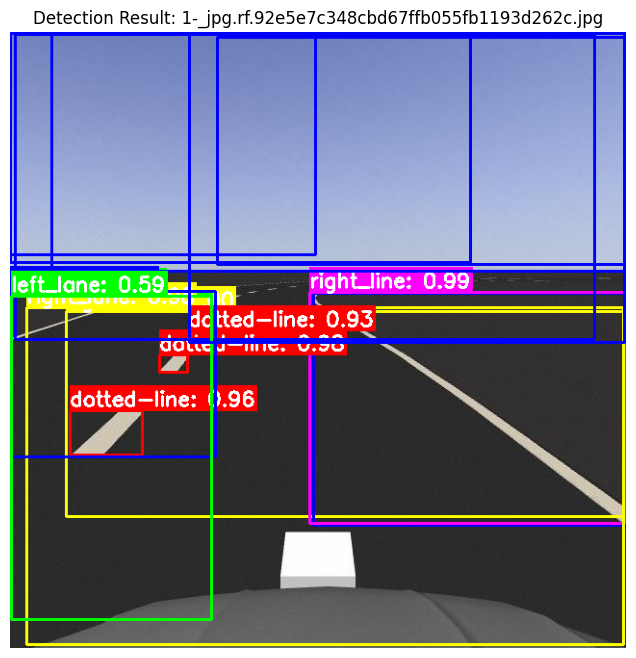

Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels


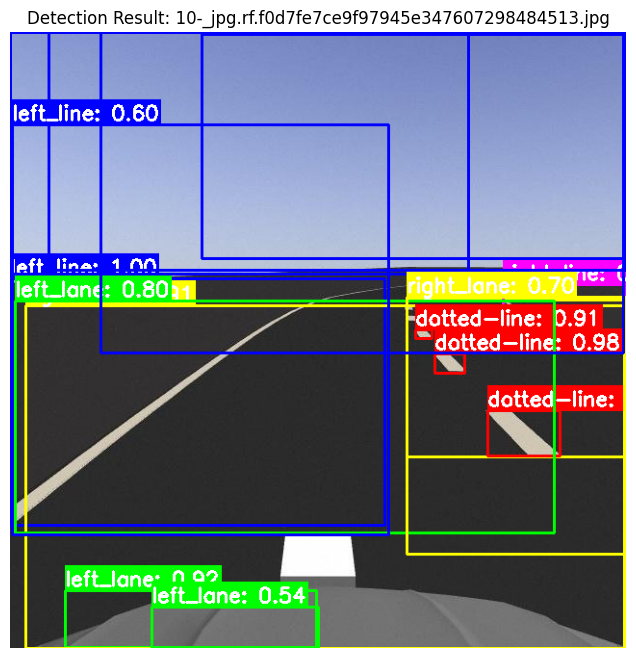

Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels


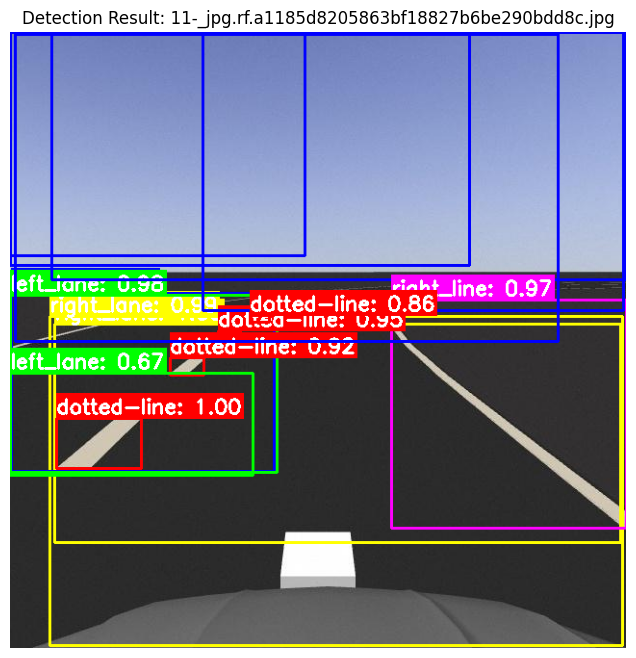

Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels


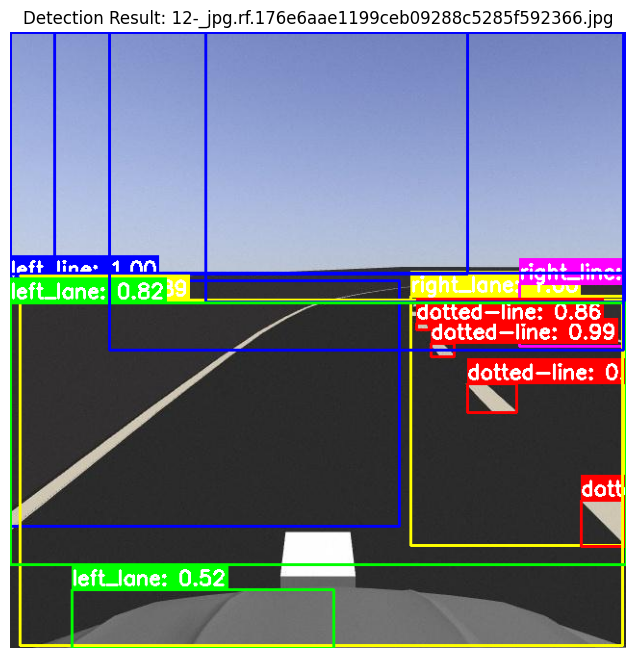

Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels


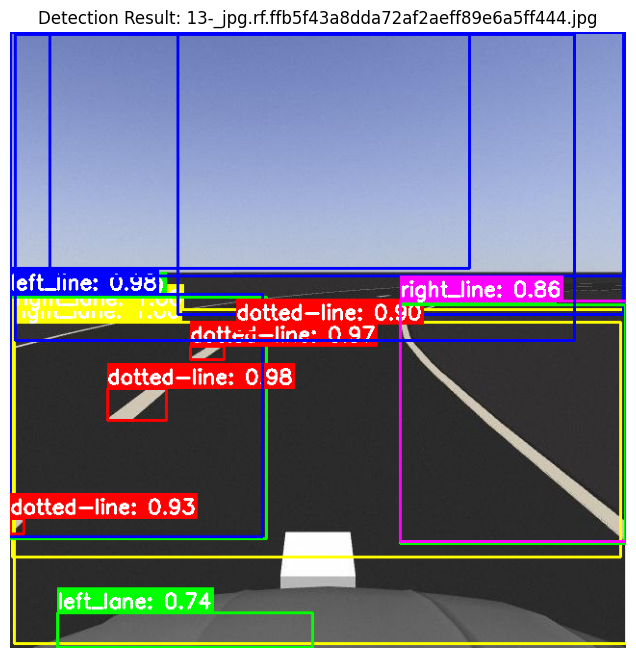

In [19]:
image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])

for i, img_name in enumerate(test_images[:5]):  # 처음 5개만
    img_path = os.path.join(image_dir, img_name)

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 바운딩 박스 시각화
    bbox_img = draw_bbox_results(img_path, result)

    # 결과 표시
    plt.figure(figsize=(12, 8))
    plt.imshow(bbox_img)
    plt.title(f'Detection Result: {img_name}')
    plt.axis('off')
    plt.show()


In [20]:
import shutil
from google.colab import files

# 1. zip 파일로 압축 (기존 zip 파일이 있다면 덮어씌움)
shutil.make_archive('/content/runs_backup', 'zip', '/content/runs')

# 2. 다운로드 링크 제공
files.download('/content/runs_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
#동영상으로 만들기
import os
import cv2
import numpy as np

image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])

frames = []

for i, img_name in enumerate(test_images[:5]):  # 처음 5개만
    img_path = os.path.join(image_dir, img_name)

    # 예측 실행
    results = model.predict(img_path, conf=0.5, save=False, verbose=False)

    # YOLO의 내부 시각화 이미지 사용
    plotted_img = results[0].plot()  # numpy 배열(BGR 형식)

    # 리사이즈
    plotted_img = cv2.resize(plotted_img, (1280, 720))

    frames.append(plotted_img)

# 🔄 동영상 생성
video_path = "/content/detection_results.mp4"
fps = 2
height, width, _ = frames[0].shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

for frame in frames:
    out.write(frame)

out.release()
print(f"✅ 영상 저장 완료: {video_path}")

# 다운로드 링크 제공
from google.colab import files
files.download(video_path)


Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels
Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels
Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels
Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels
Results saved to /content/Test.v1i.yolov8.zip2.zip
15 labels saved to /content/Test.v1i.yolov8.zip2.zip/labels
✅ 영상 저장 완료: /content/detection_results.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>